In [29]:
#Task 1 — Data Loading & Exploration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Housing.csv")

In [3]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [30]:
#Task 2 — Data Cleaning
df.drop_duplicates(inplace=True)

In [8]:
print(df.shape)

(545, 13)


In [9]:
df.fillna(df.mode().iloc[0], inplace=True)

In [10]:
df.select_dtypes(include='object').columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [11]:
df = pd.get_dummies(df, drop_first=True)

In [12]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [31]:
#Task 3 — Model Building
X = df.drop("price", axis=1)
y = df["price"]

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [34]:
#Model 1: Linear Regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
lr_pred = lr.predict(X_test)

In [17]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
mae_lr = mean_absolute_error(y_test, lr_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_pred))
r2_lr = r2_score(y_test, lr_pred)
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

MAE: 970043.4039201637
RMSE: 1324506.9600914388
R2: 0.6529242642153184


In [35]:
#Model 2: Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [19]:
mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
r2_rf = r2_score(y_test, rf_pred)
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

MAE: 1021546.0353211008
RMSE: 1400565.9728553821
R2: 0.611918531405699


In [36]:
#Compare Models
results = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "MAE":[mae_lr,mae_rf],
    "RMSE":[rmse_lr,rmse_rf],
    "R2":[r2_lr,r2_rf]})
results

,Model,MAE,RMSE,R2
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


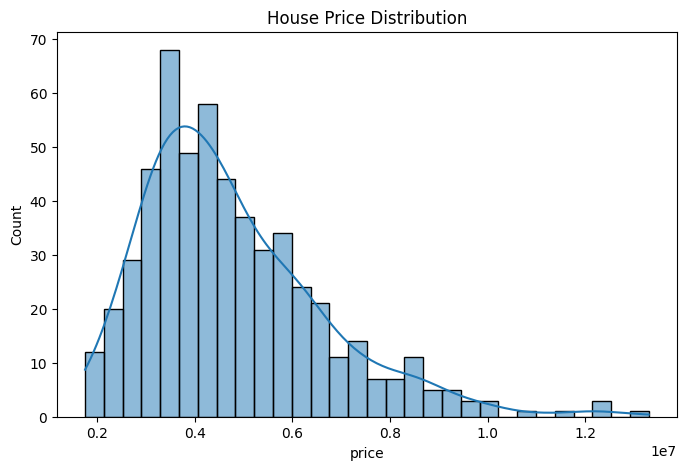

In [37]:
#Task 4 — Visualization
#Chart 1: House Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['price'],bins=30,kde=True)
plt.title("House Price Distribution")
plt.savefig("charts/price_distribution.png")
plt.show()

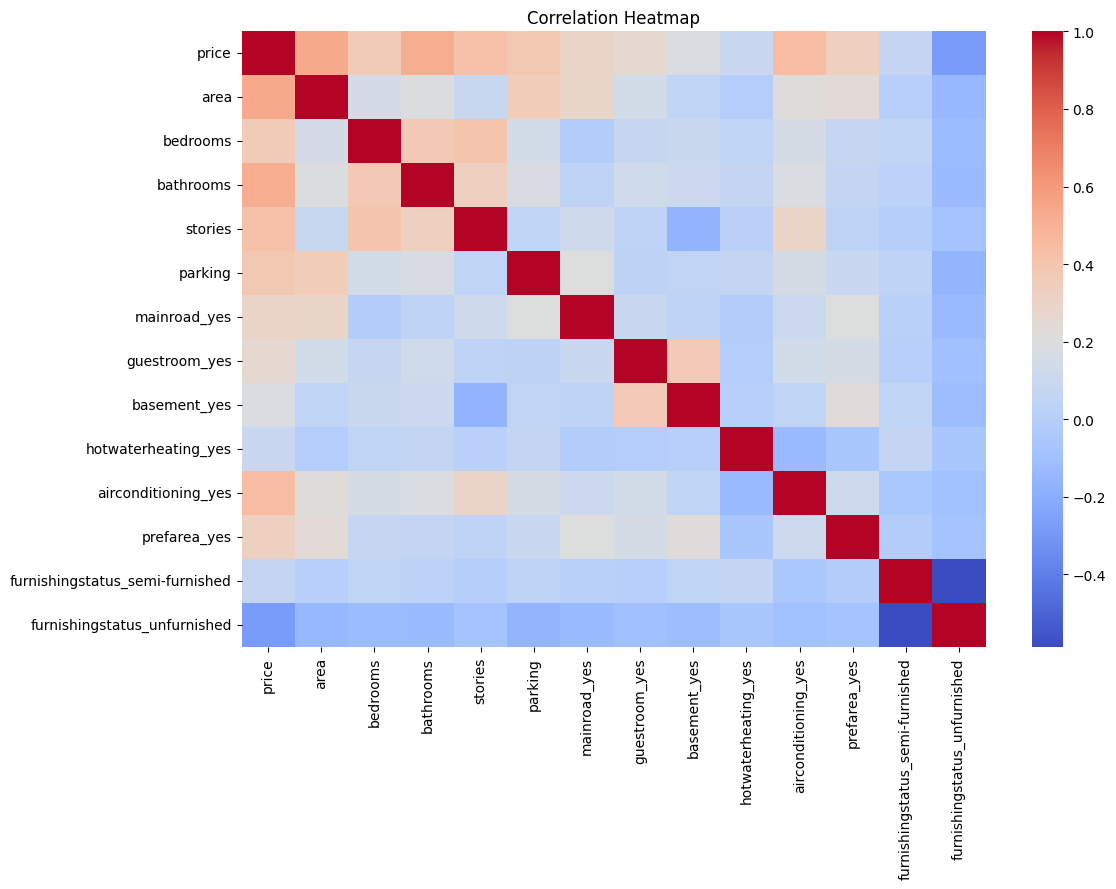

In [38]:
#Chart 2: Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("charts/correlation_heatmap.png")
plt.show()

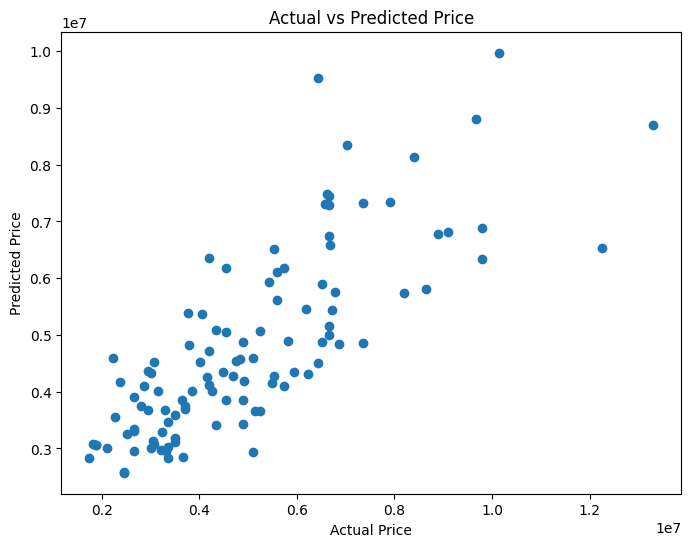

In [39]:
#Chart 3: Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test,rf_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.savefig("charts/actual_vs_predicted.png")
plt.show()

In [40]:
#Feature Importance
importance = pd.DataFrame({"Feature":X.columns,"Importance":rf.feature_importances_})
importance = importance.sort_values(by="Importance",ascending=False)
importance.head(10)

,Feature,Importance
0,area,0.468430
2,bathrooms,0.151483
9,airconditioning_yes,0.062672
4,parking,0.057455
3,stories,0.057133
1,bedrooms,0.048413
12,furnishingstatus_unfurnished,0.035011
7,basement_yes,0.030823
10,prefarea_yes,0.030689
8,hotwaterheating_yes,0.017226


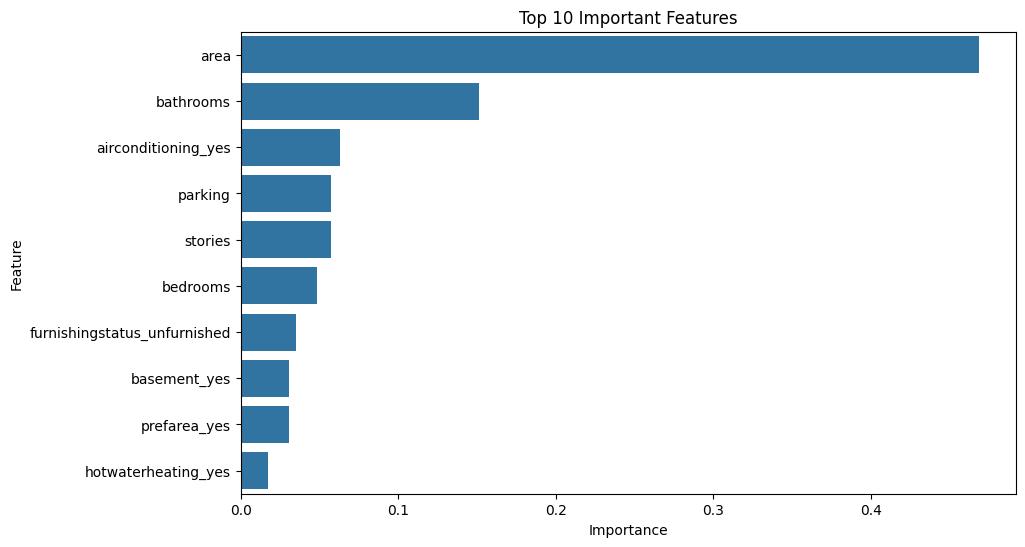

In [28]:
plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(10),x="Importance",y="Feature")
plt.title("Top 10 Important Features")
plt.show()